In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from PIL import Image 
import imageio
import os

# Act 2.1. Familiarization with Discrete FT

In [2]:
def circle_gen(radius_percent, resolution): # first arg from 0 to 1, 1 means radius = half of resolution
    N = resolution 
    x = np.linspace(-1, 1, num=N)
    y = x
    X, Y = np.meshgrid(x,y)
    R = np.sqrt(X**2 + Y**2)
    A = np.zeros(np.shape(R))
    A[np.where(R<radius_percent)] = 1  
    
    return A 


def diffraction_pattern(A):  # arg is the aperture image, must be nxn sized
    fourier_A = np.fft.fft2(A)
    fourier_A_abs = np.abs(fourier_A)        # this is the real part that manifests in reality,
                                             # but it's not shifted yet so we need to fix
    fourier_A_shifted = np.fft.fftshift(fourier_A)
    fourier_A_shifted_abs = np.abs(fourier_A_shifted)  
    
    return fourier_A_shifted_abs # this is the diffraction pattern image 

A = circle_gen(0.03, 256)
fourier_A_shifted_abs = diffraction_pattern(A)
# plt.axis('off')
# plt.imshow(A, cmap = 'gray')

C:\Users\Edneil\AppData\Local\Temp\ipykernel_15844\3535317093.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(1,2)


FileNotFoundError: [WinError 2] The system cannot find the file specified: 'Results/Animation/l'

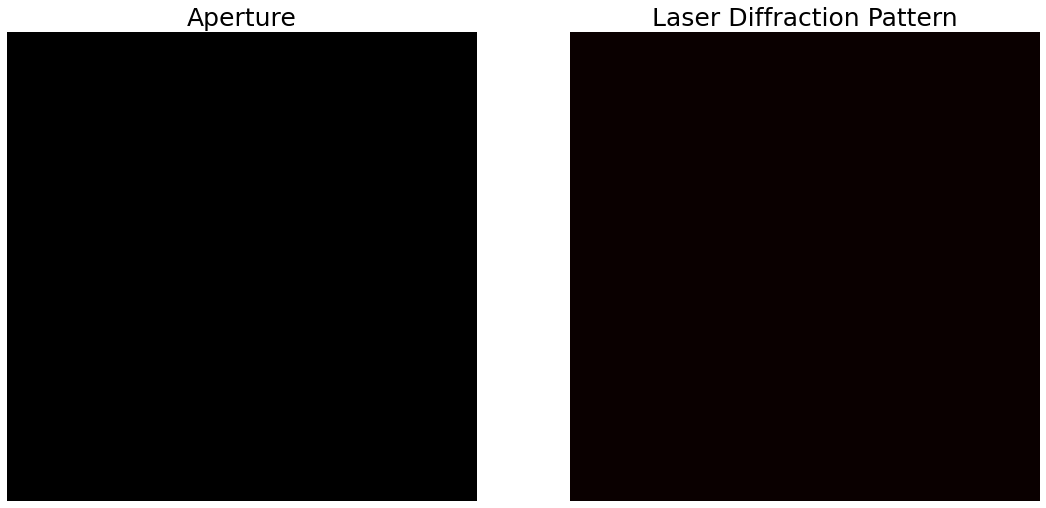

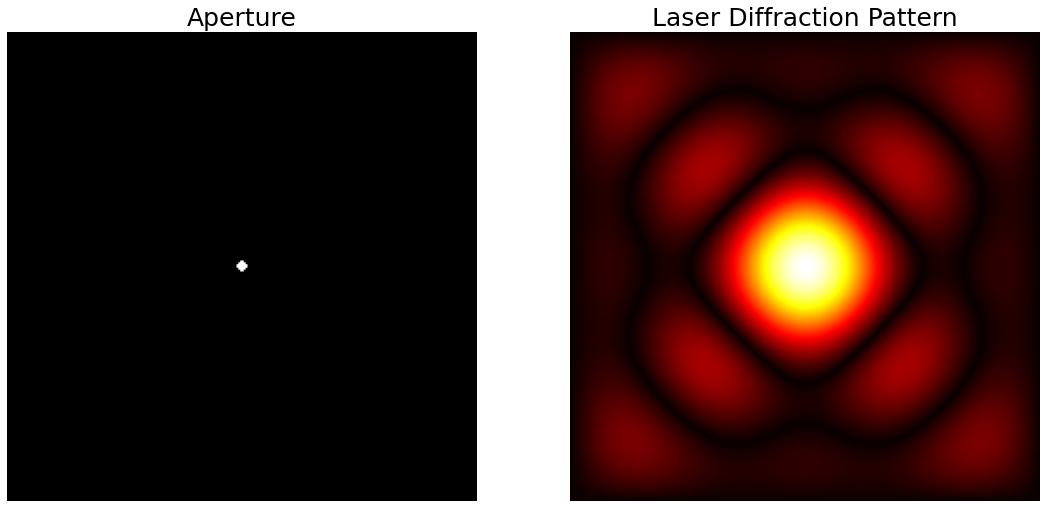

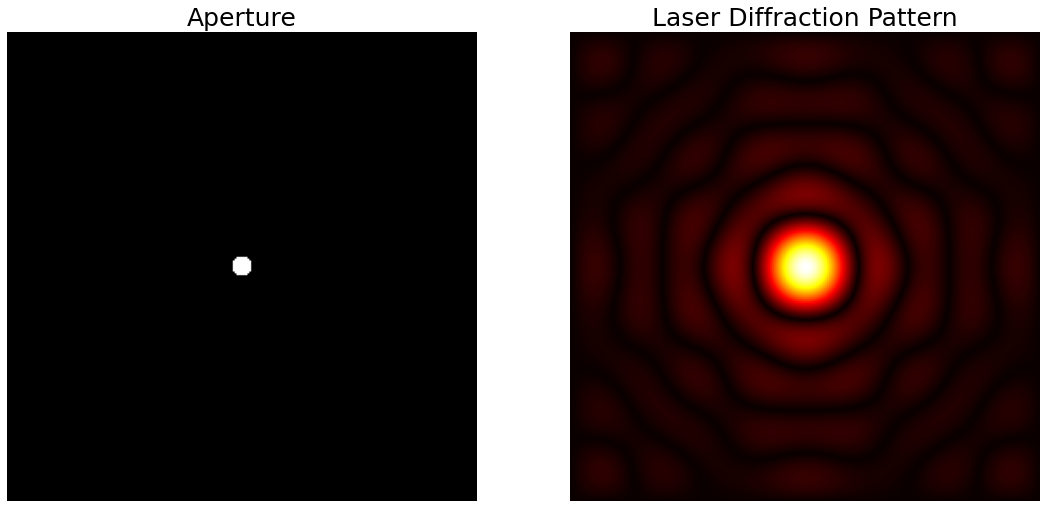

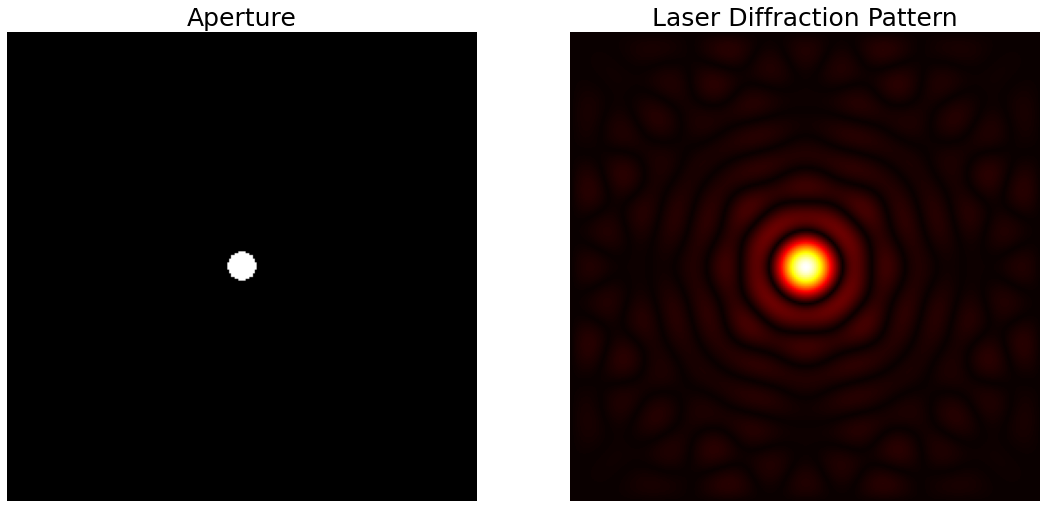

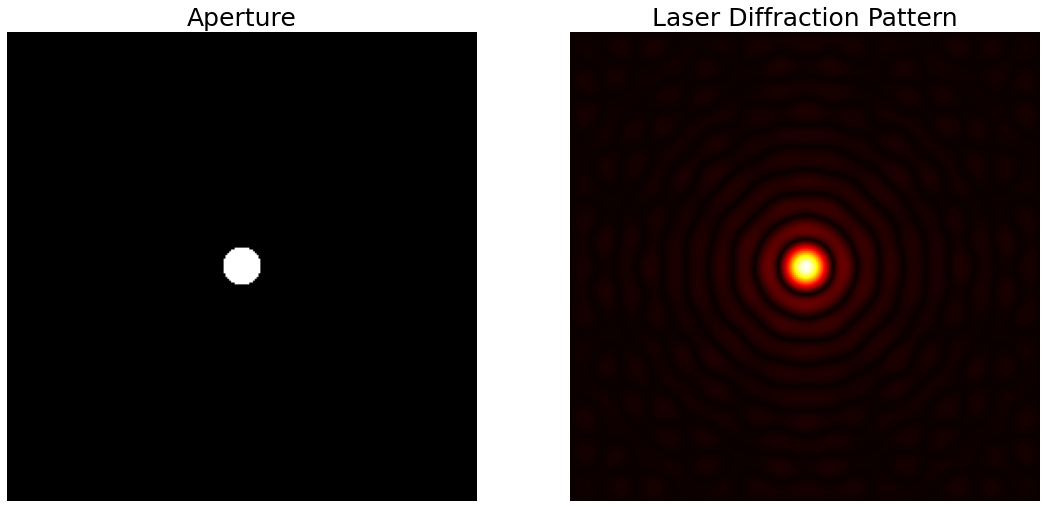

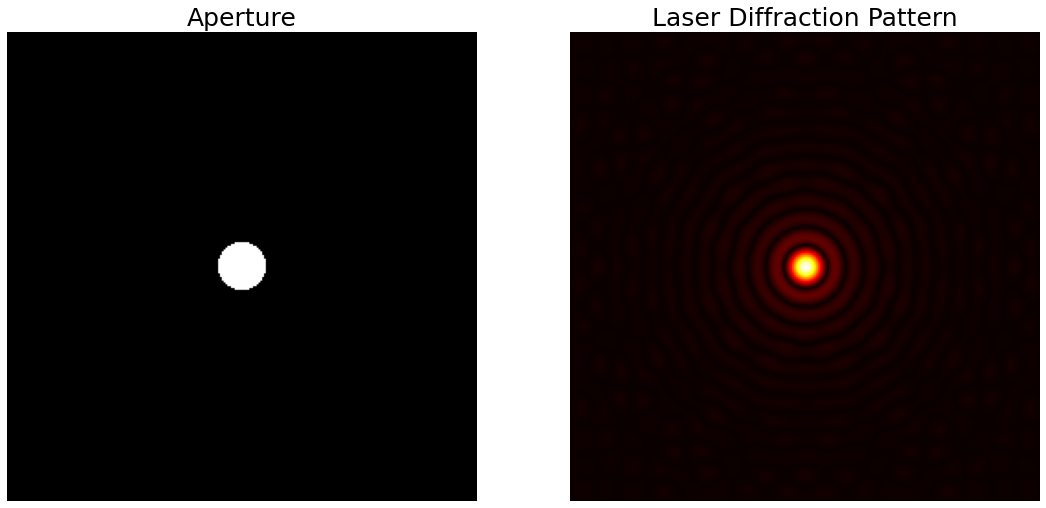

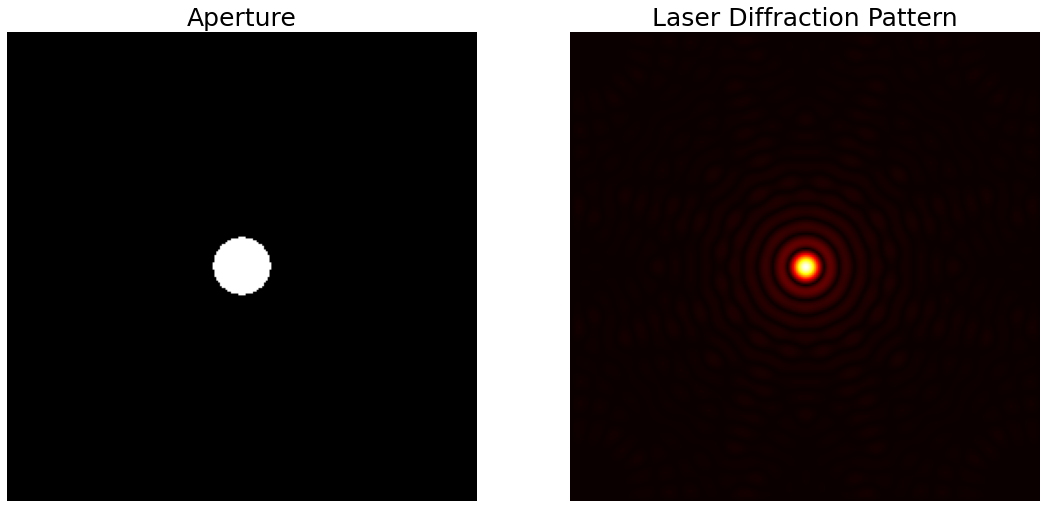

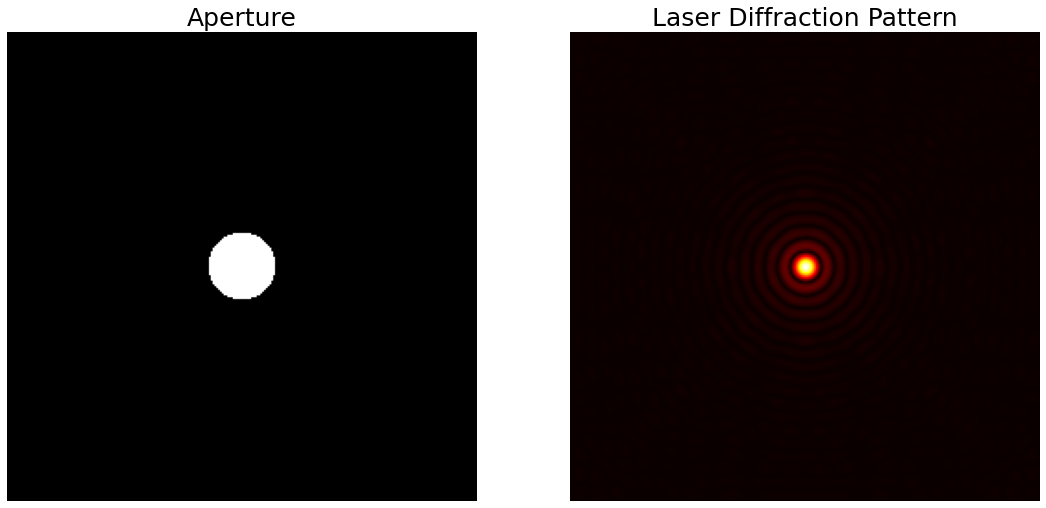

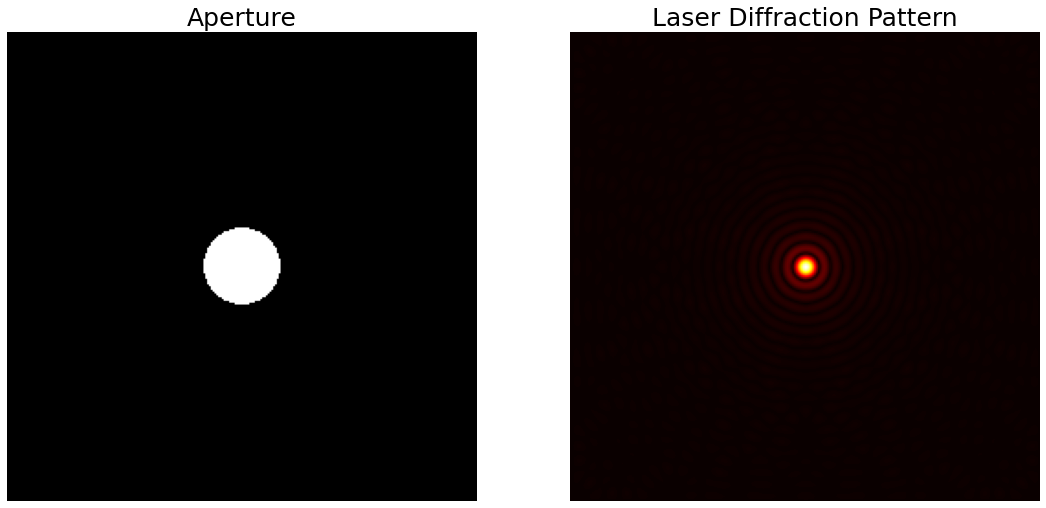

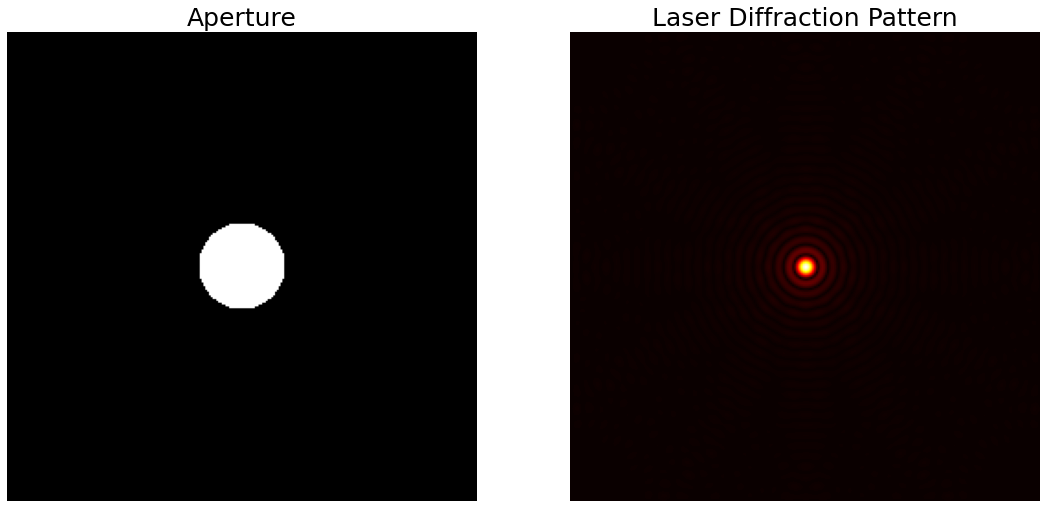

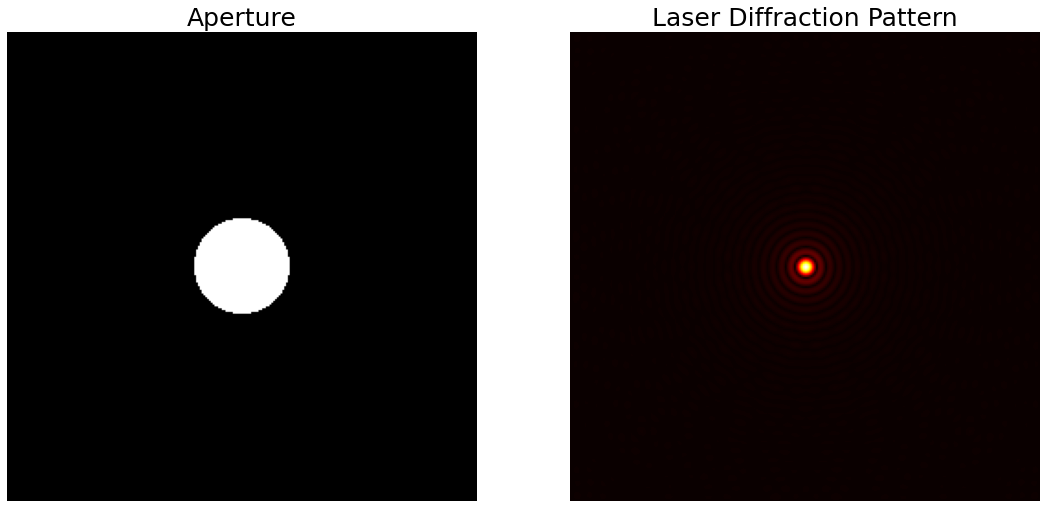

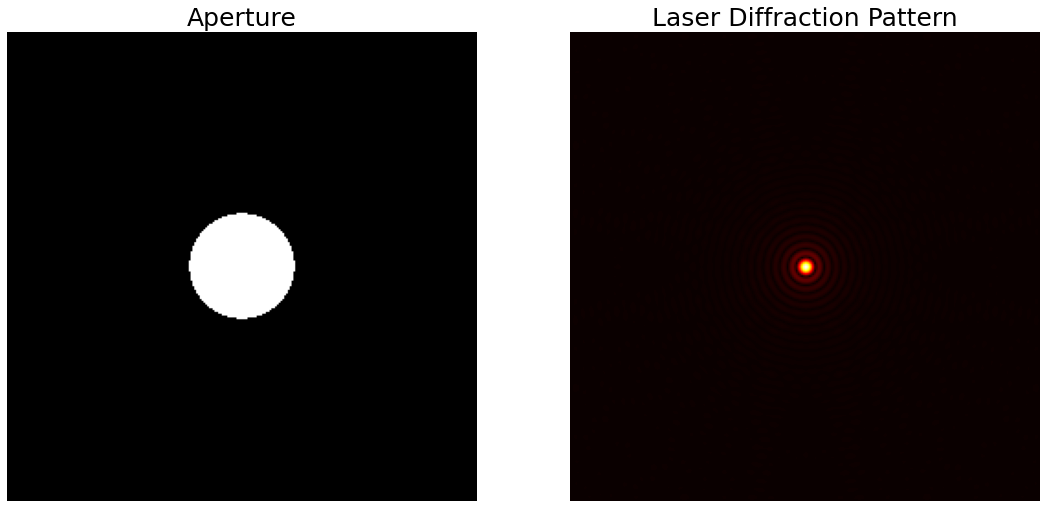

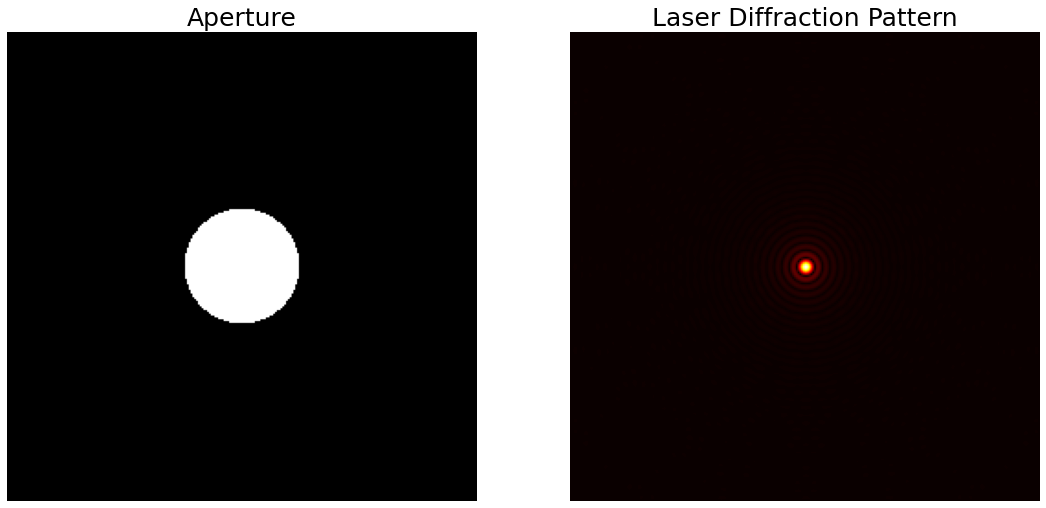

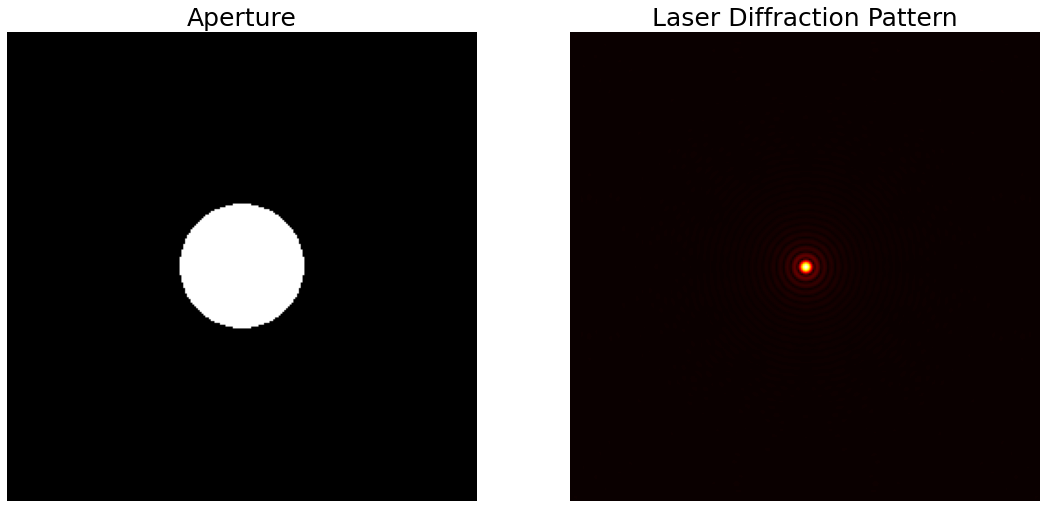

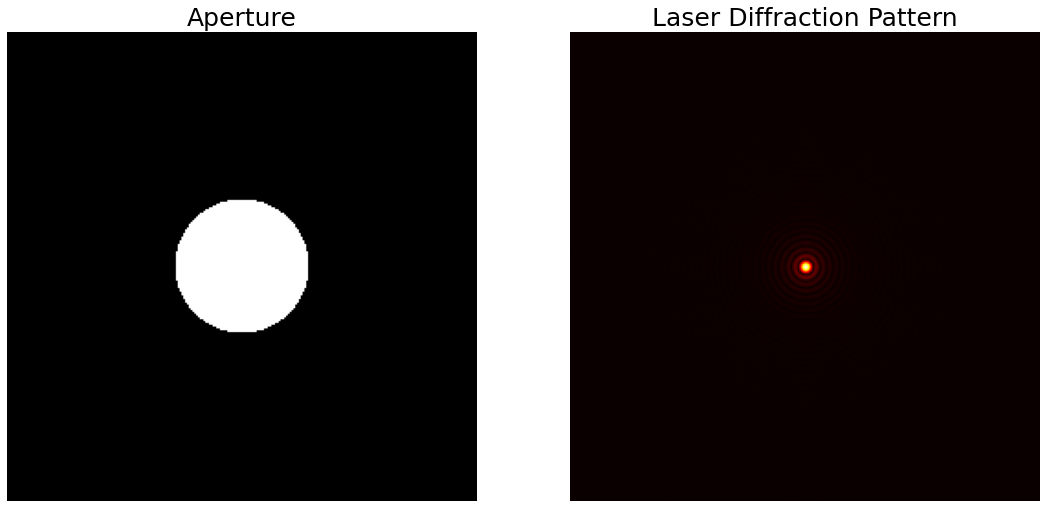

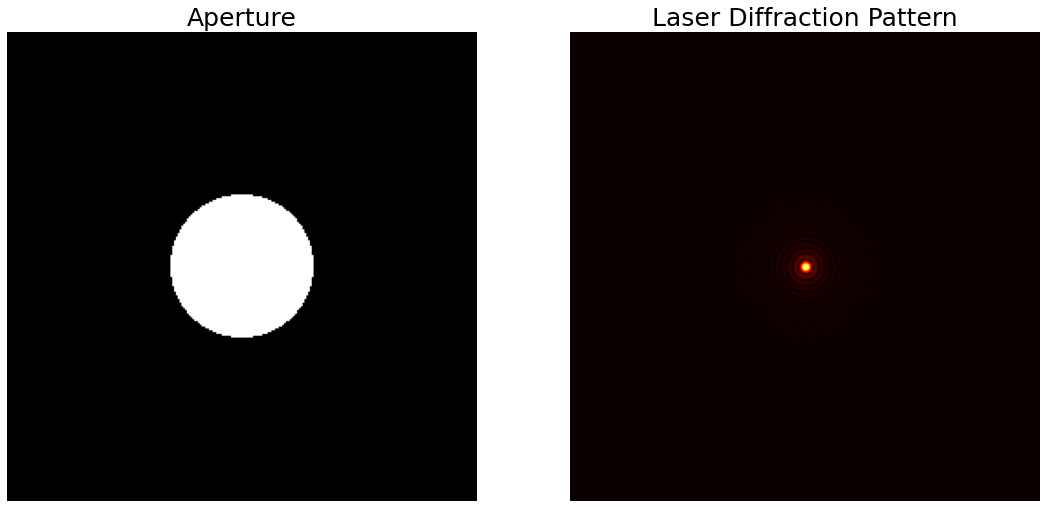

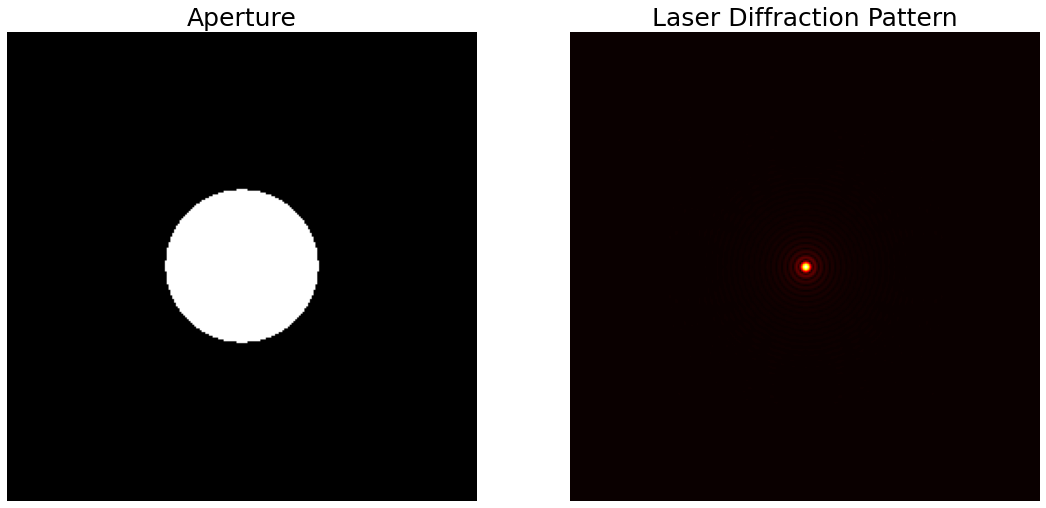

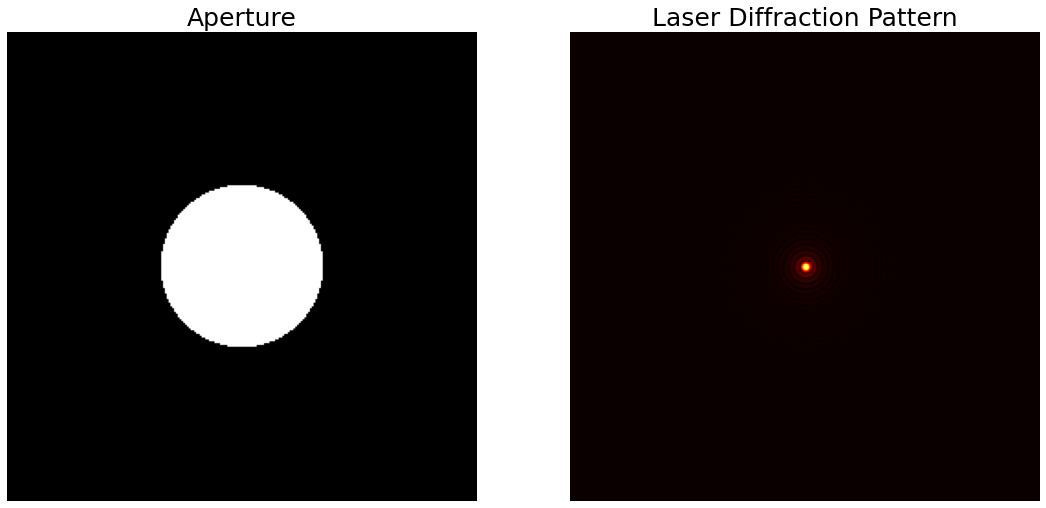

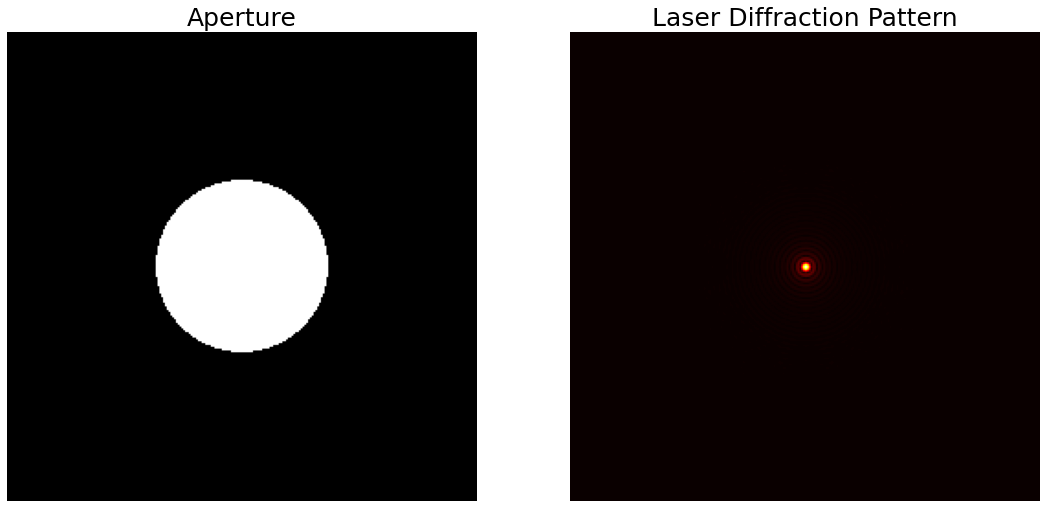

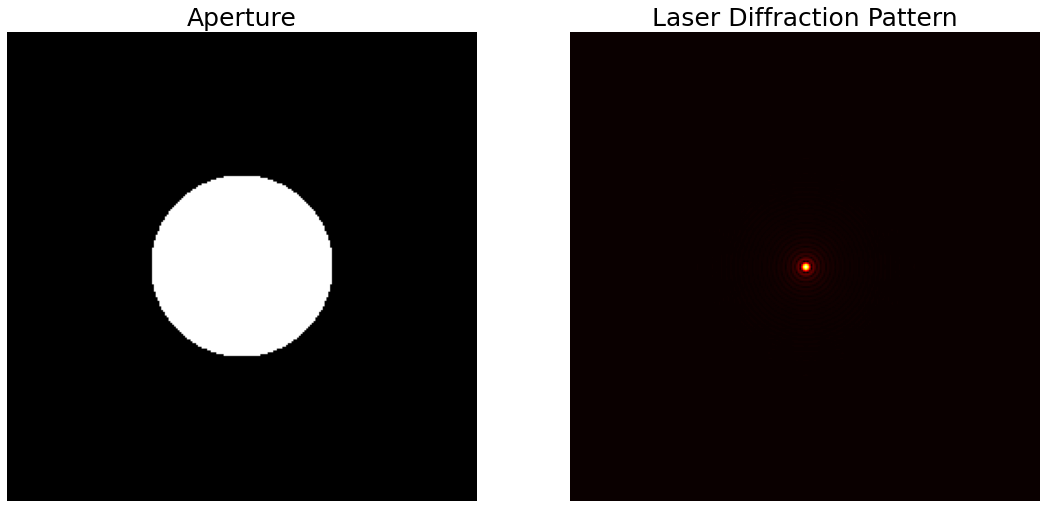

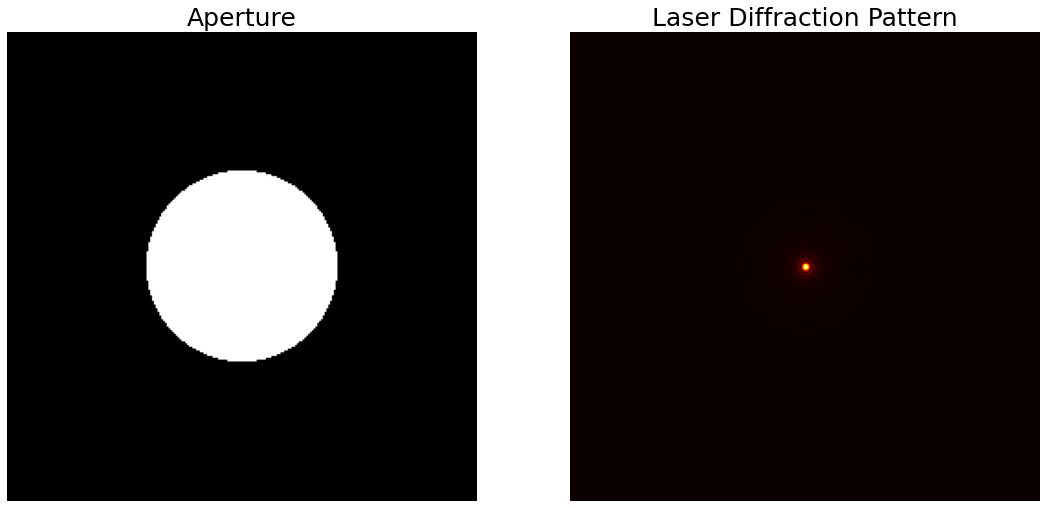

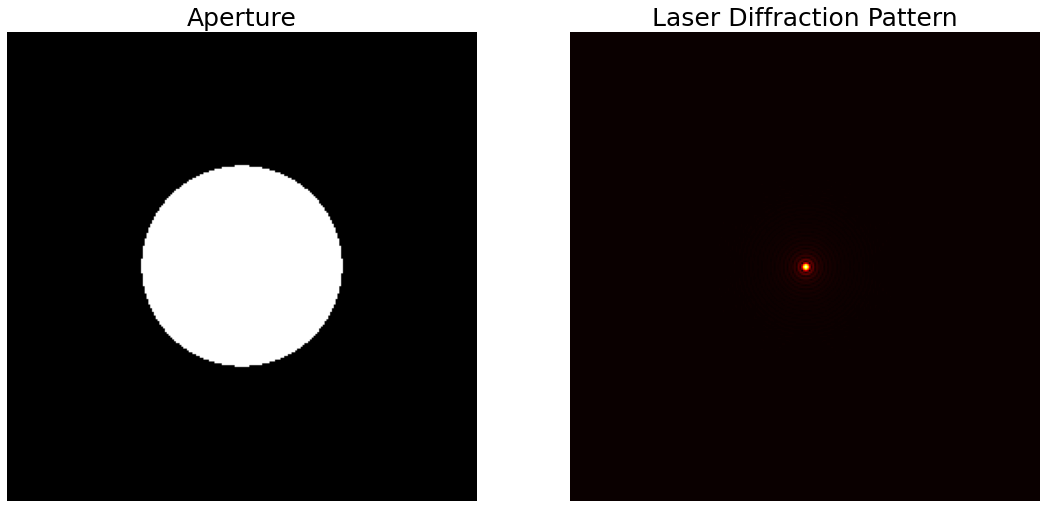

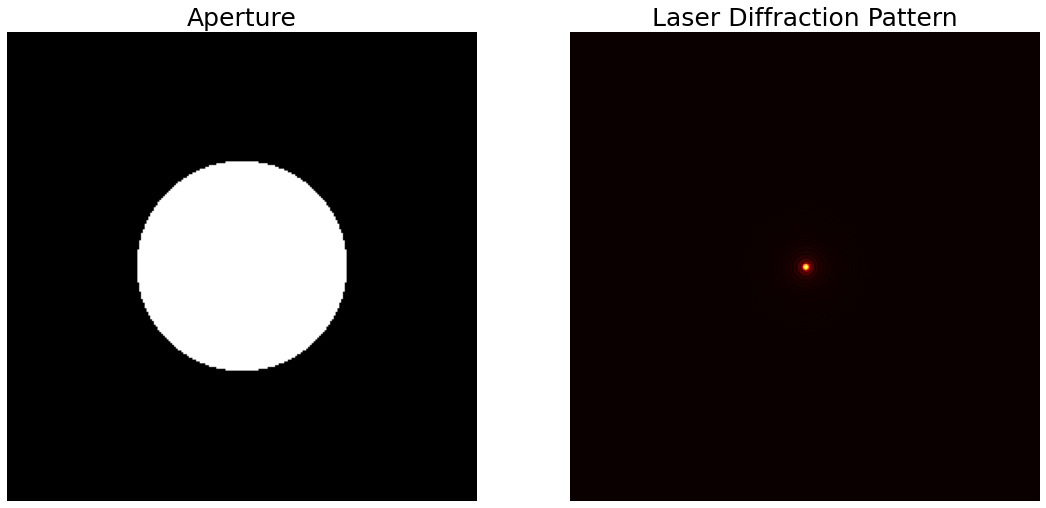

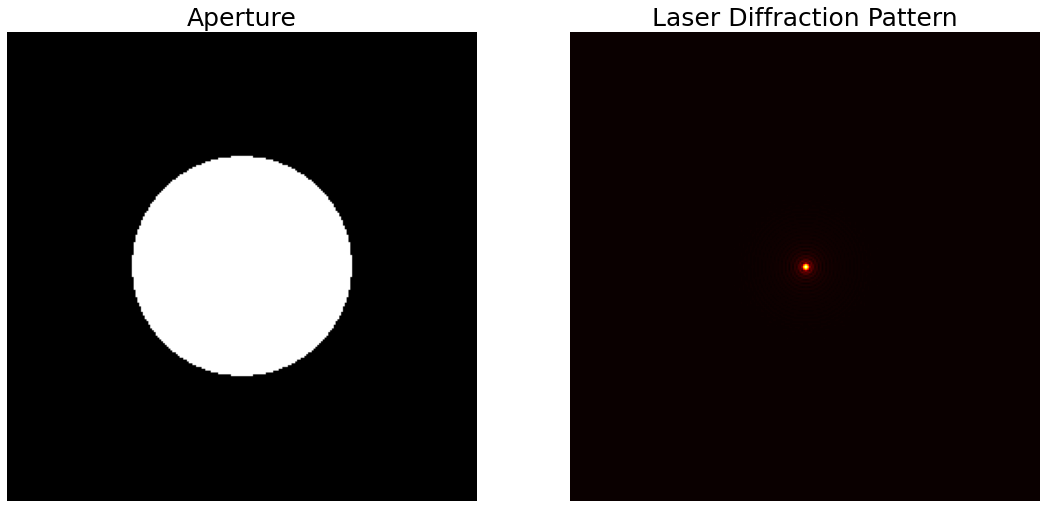

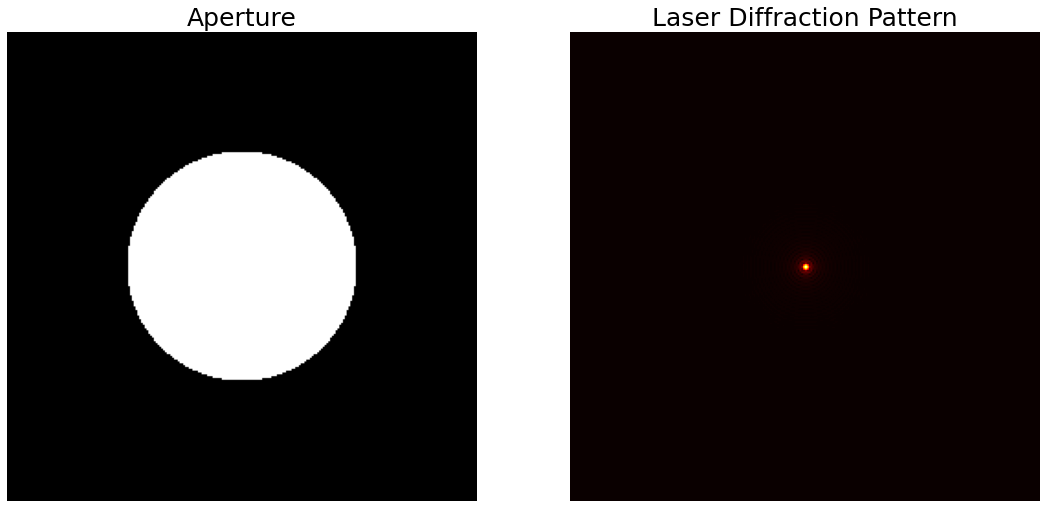

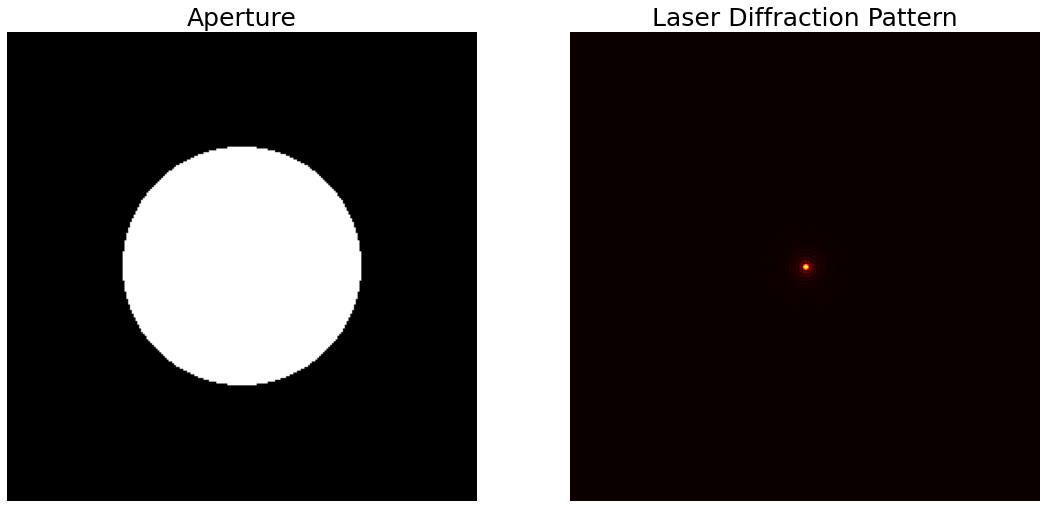

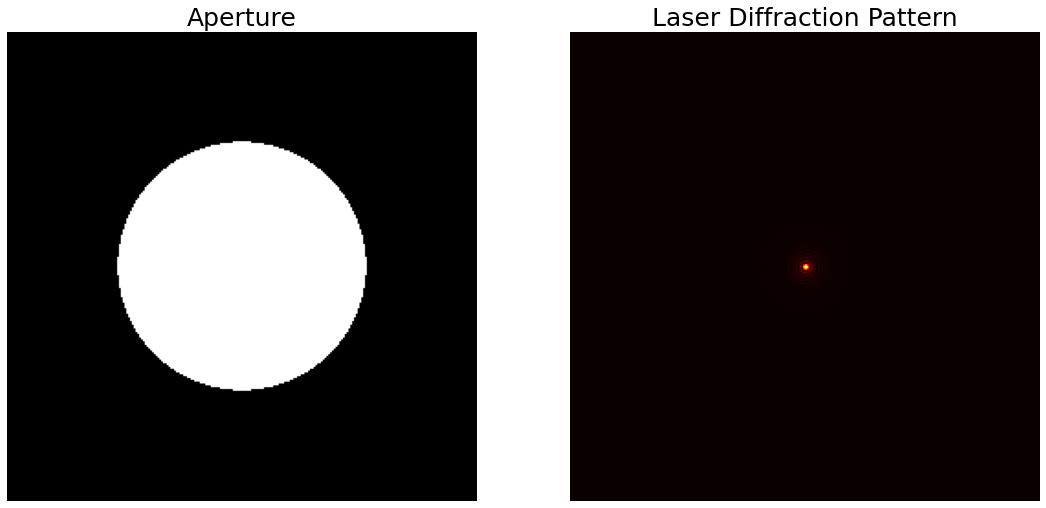

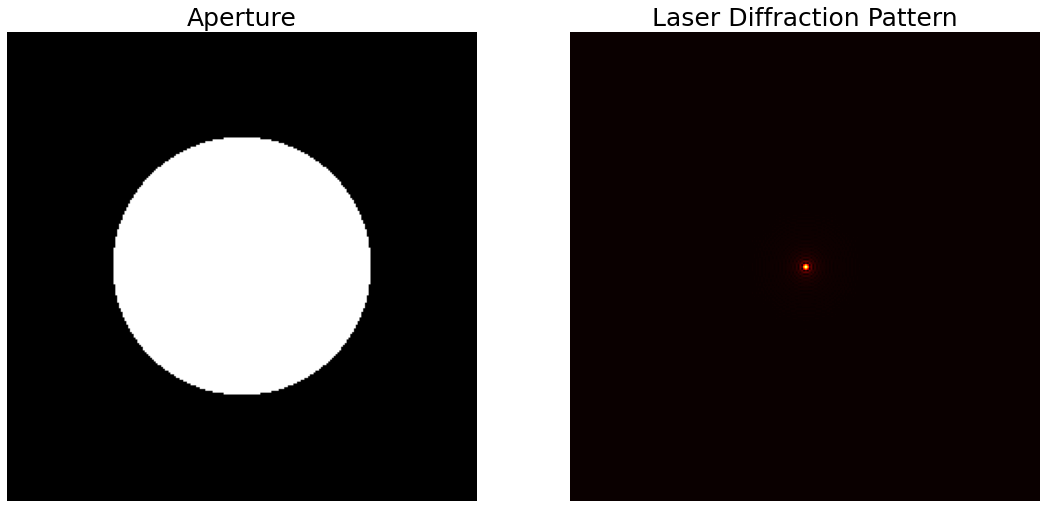

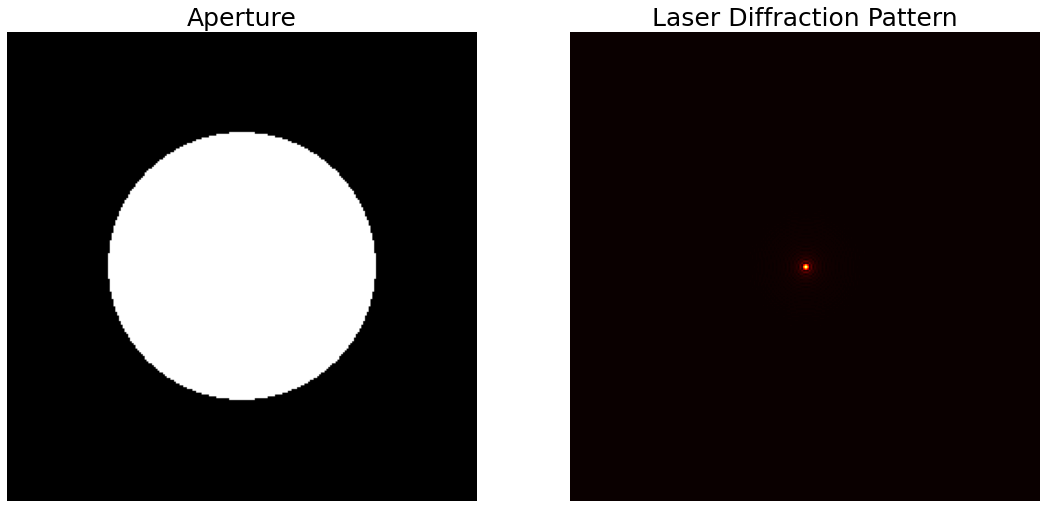

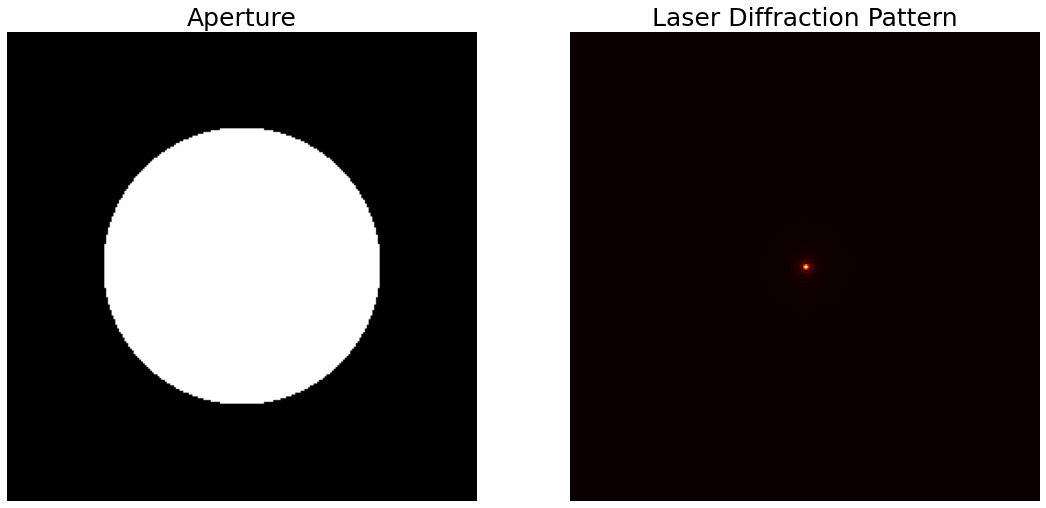

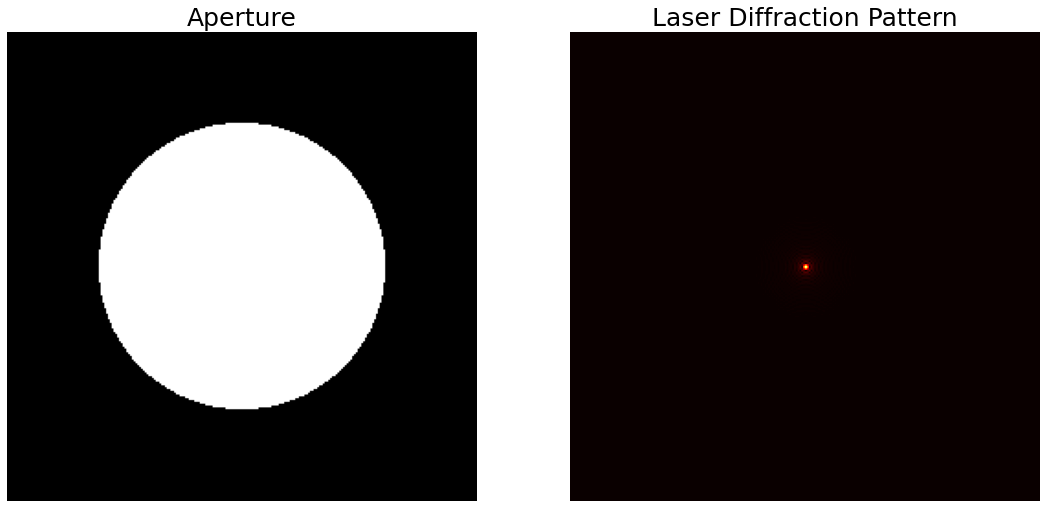

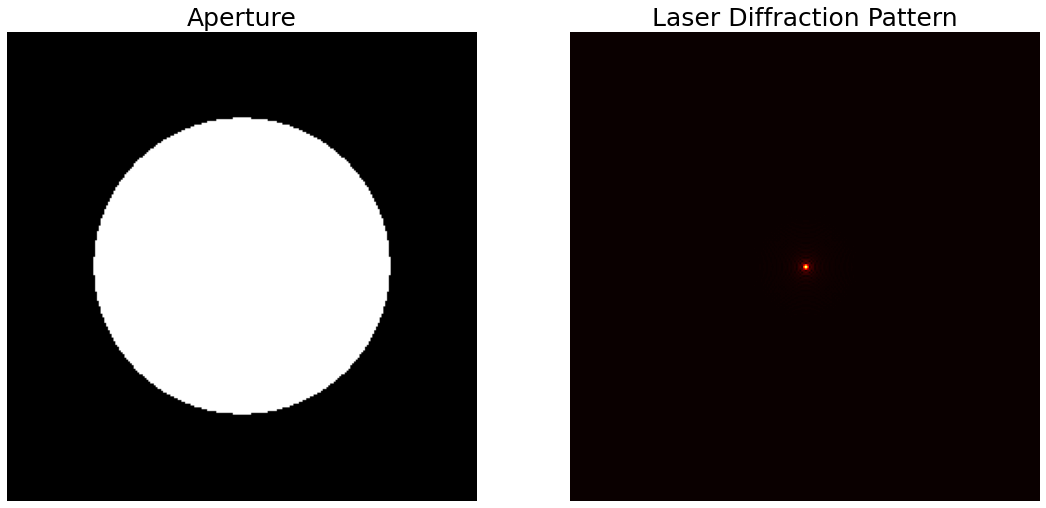

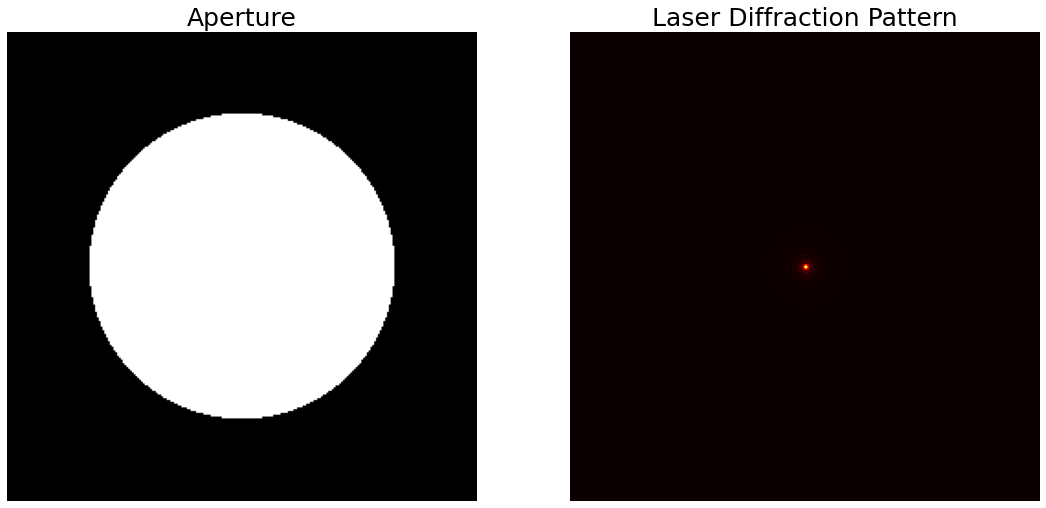

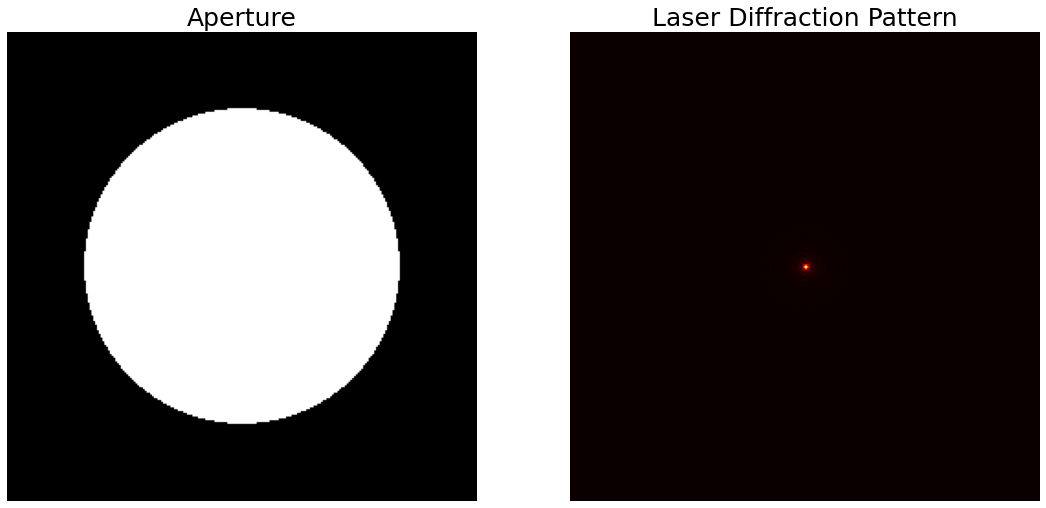

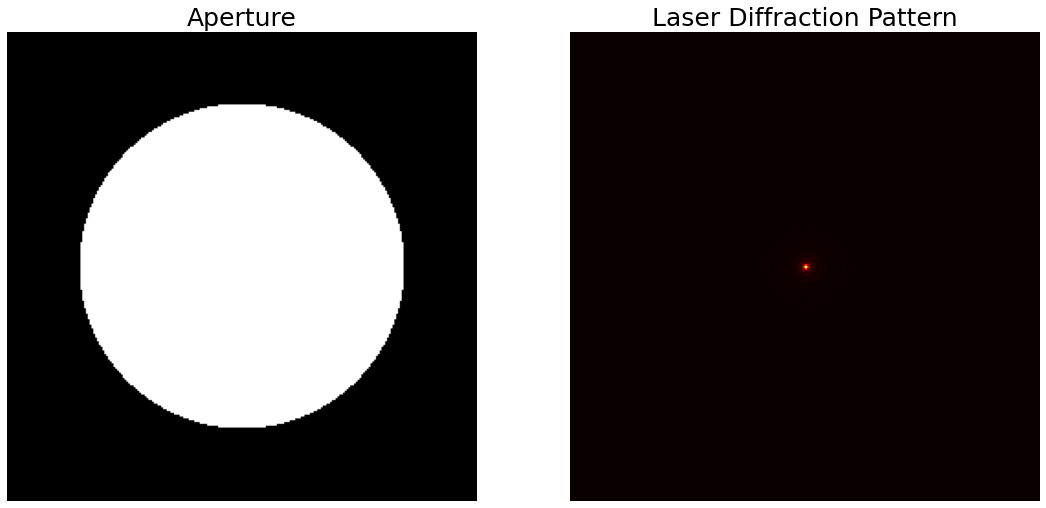

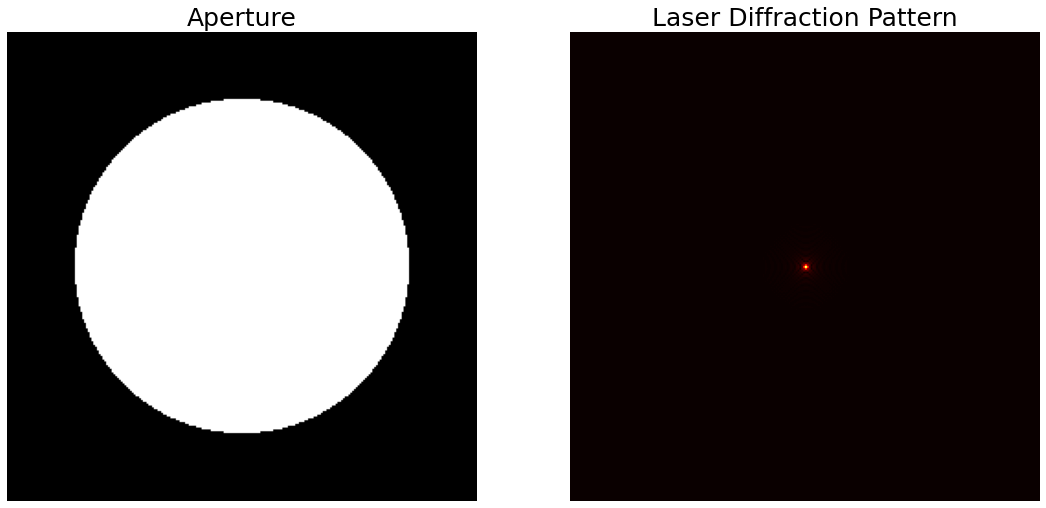

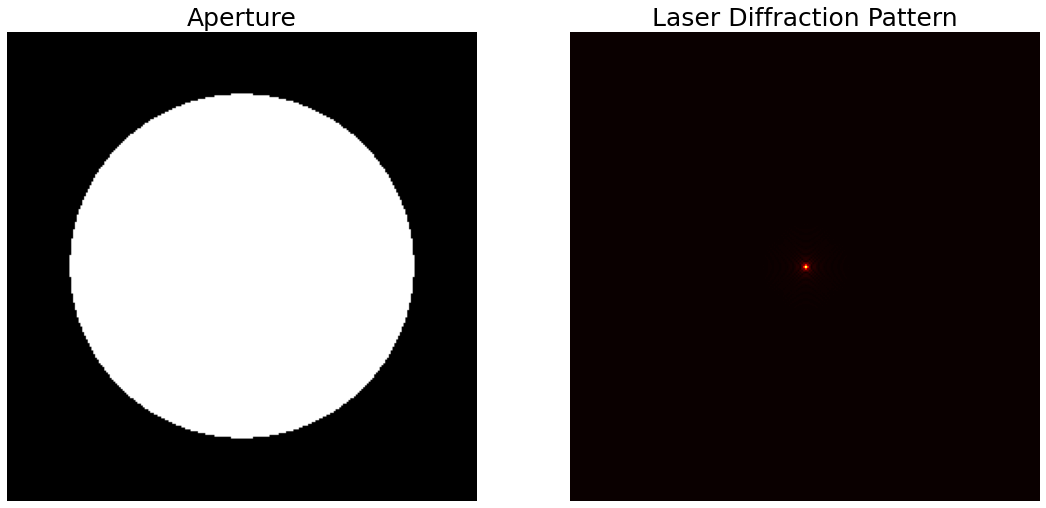

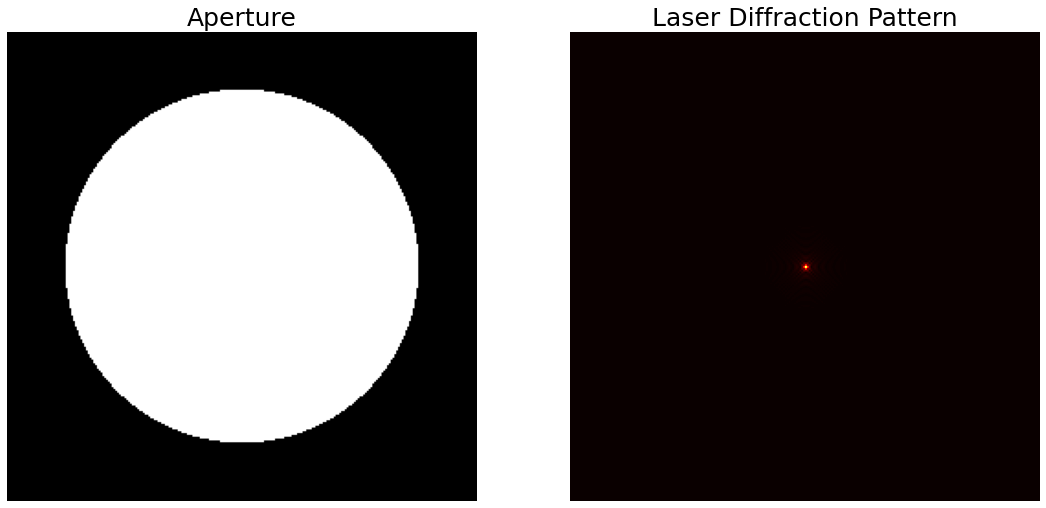

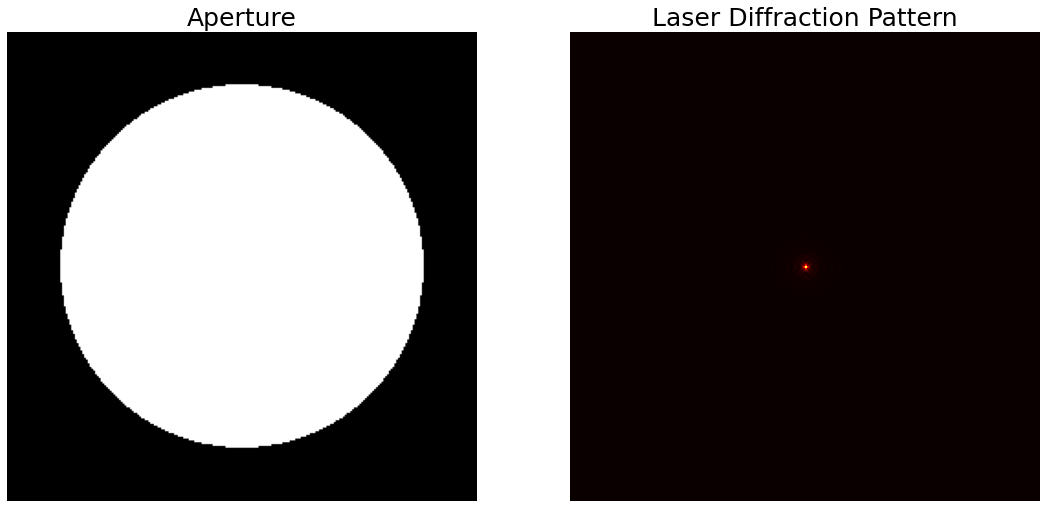

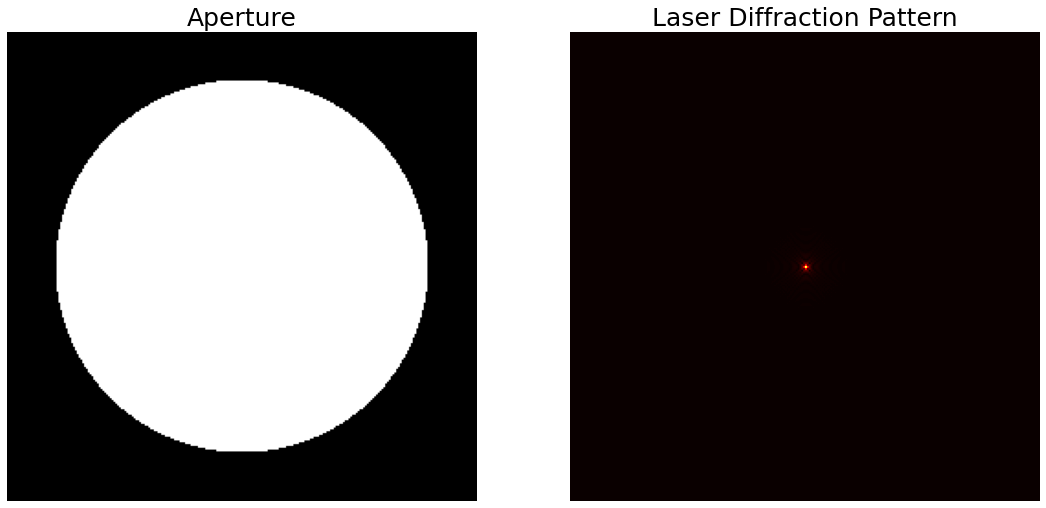

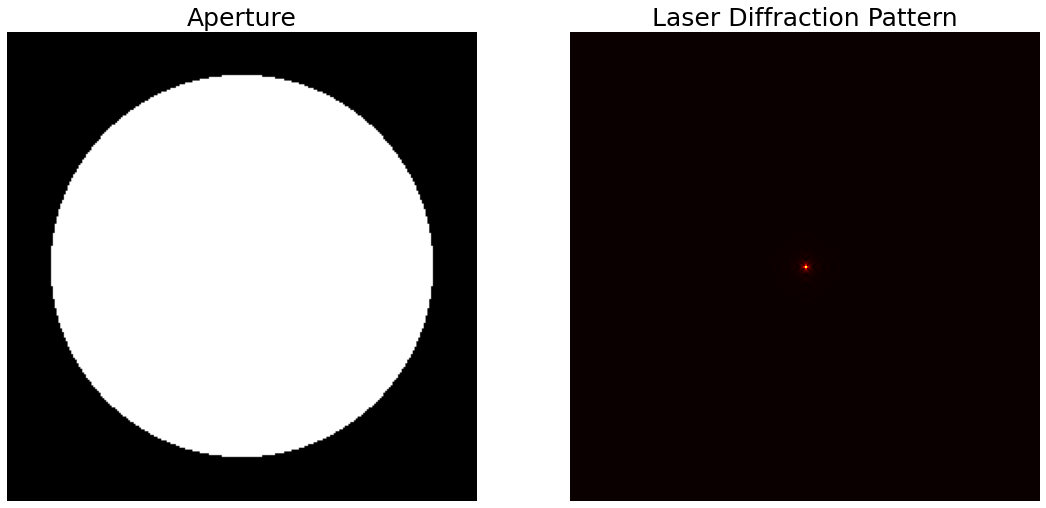

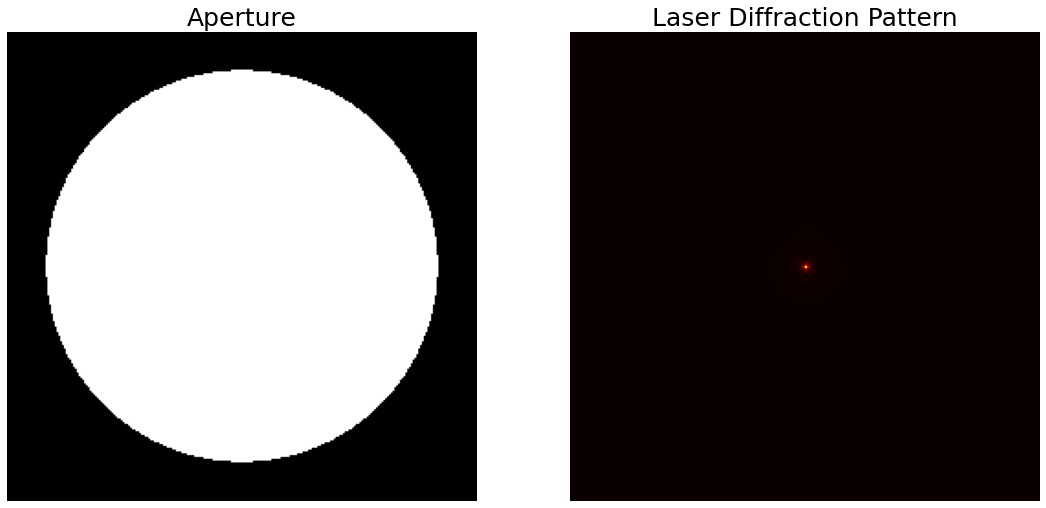

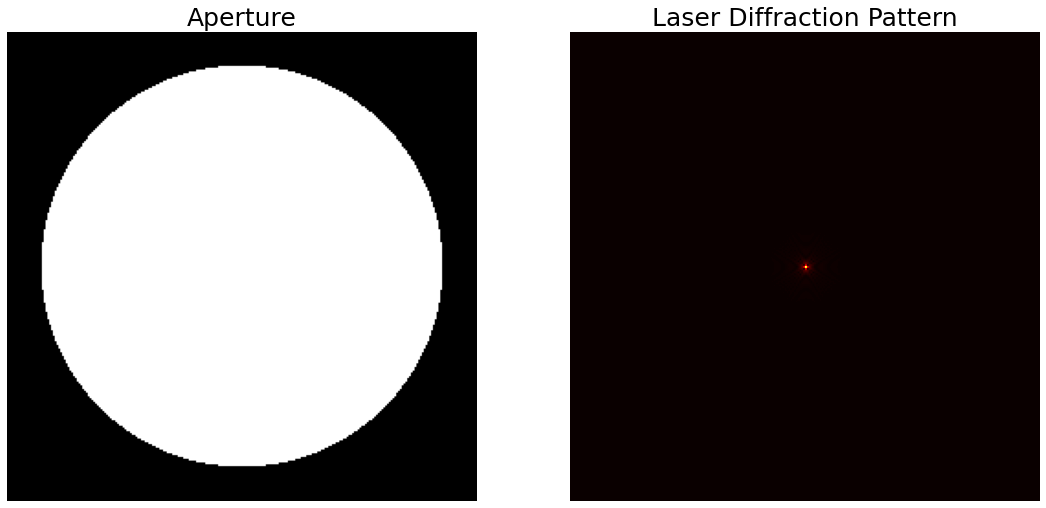

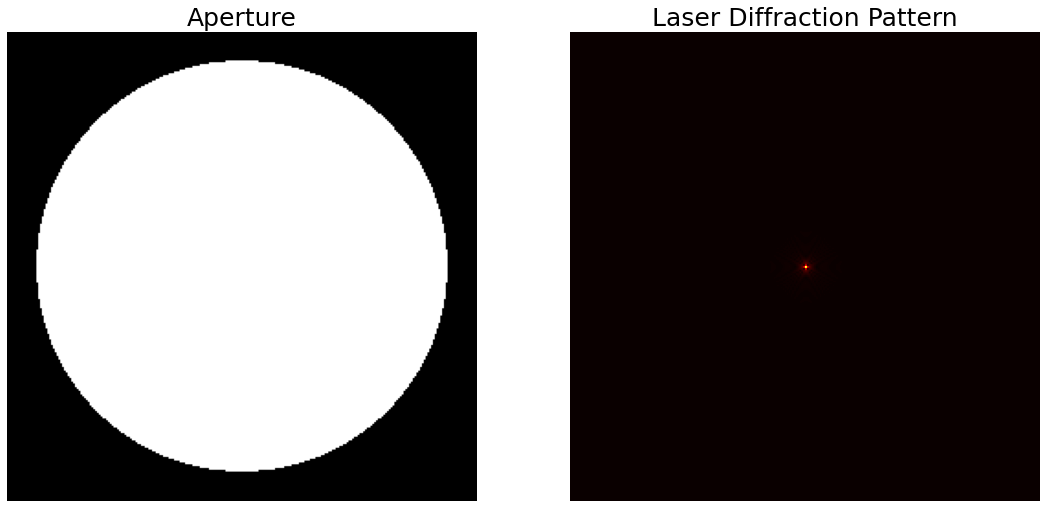

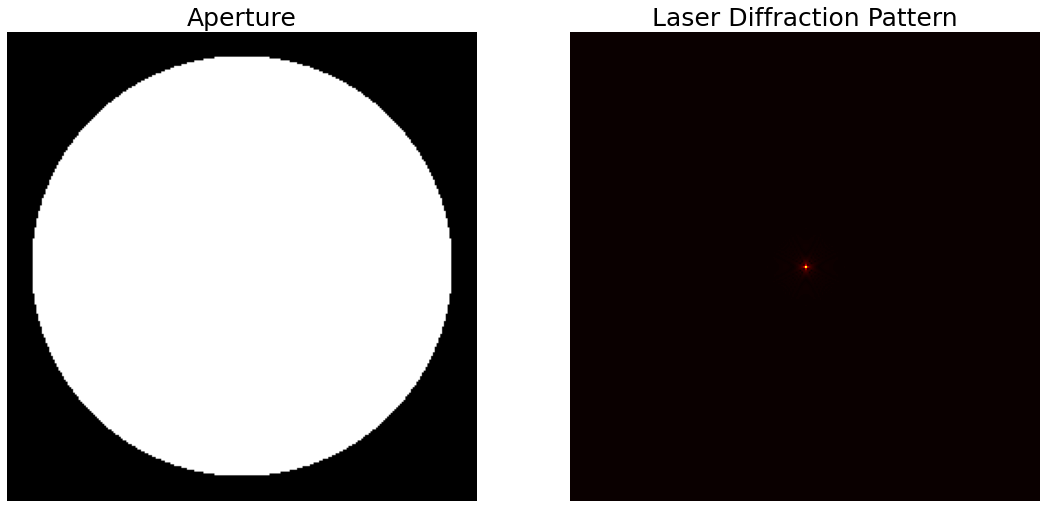

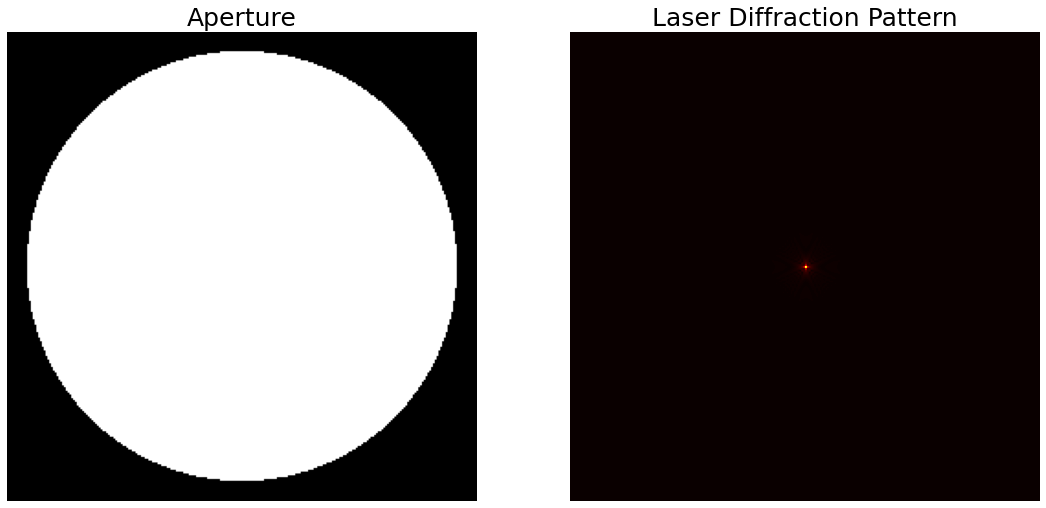

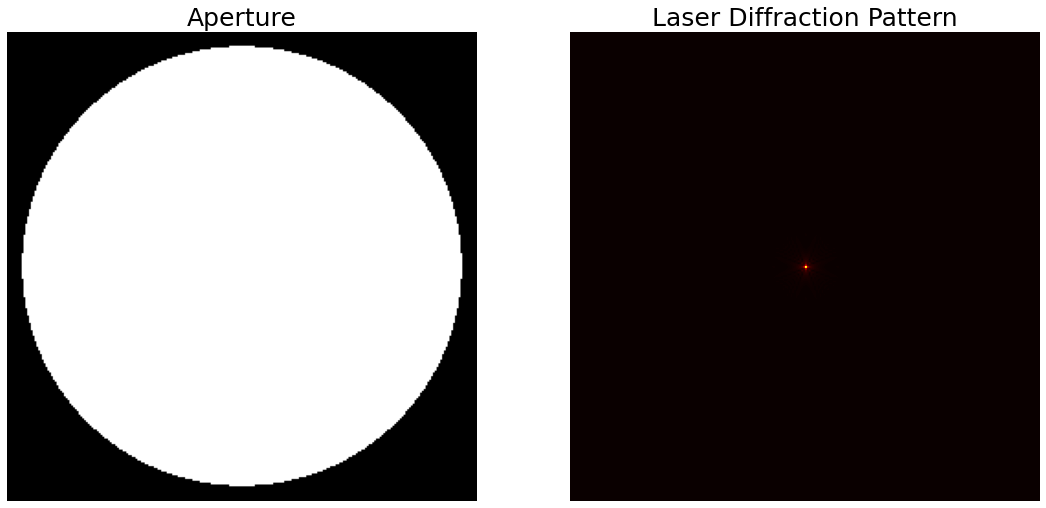

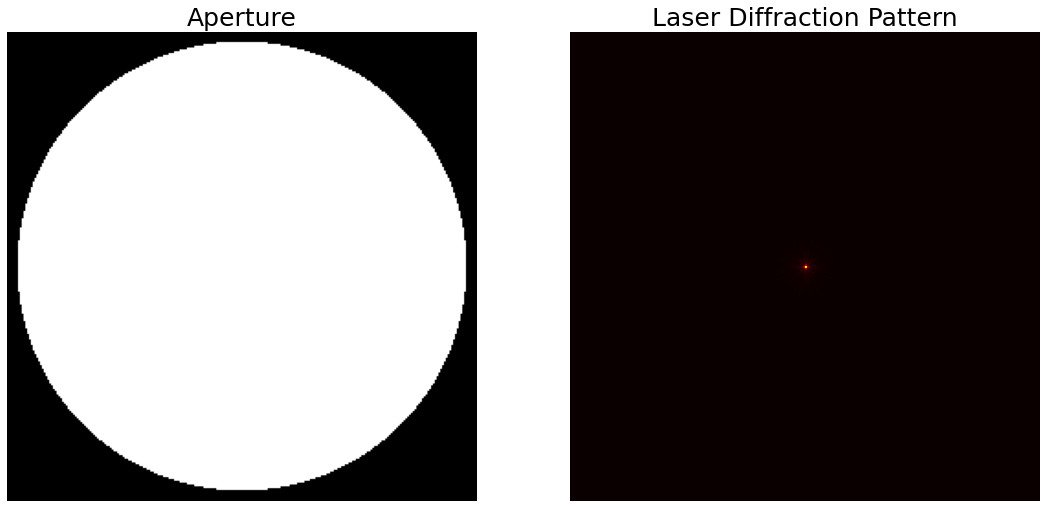

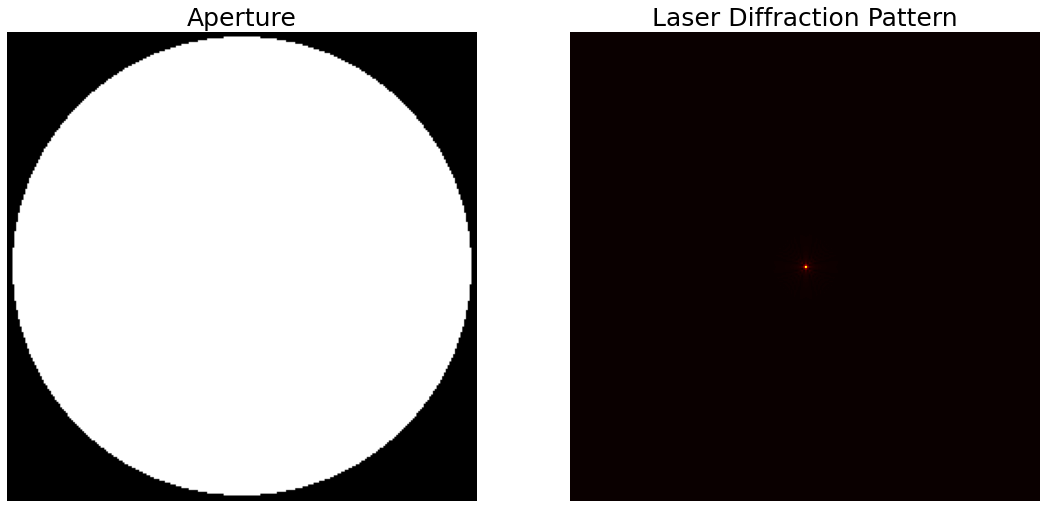

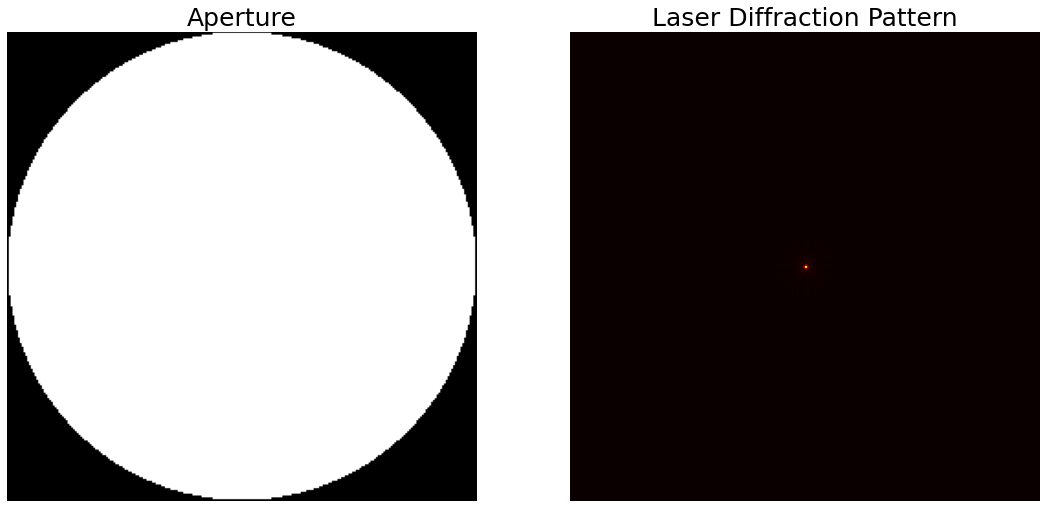

In [3]:
filenames = []    # this is for animation 
steps = 50
radii_relative = np.linspace(0.0001,1,steps)
count = 0
for i in radii_relative:    # we basically repeat the process for whatever steps animate
    count +=1 
    A = circle_gen(i, 256)                          # generate circle aperture
    fourier_A_shifted_abs = diffraction_pattern(A)  # calculate diffraction pattern
    
    fig, ax = plt.subplots(1,2) 
    
    ax[0].imshow(A, cmap='gray')
    ax[1].imshow(fourier_A_shifted_abs, cmap='hot')
    
    ax[0].set_title('Aperture', fontsize='25')
    ax[1].set_title('Laser Diffraction Pattern', fontsize='25')
    
    ax[0].axis('off')
    ax[1].axis('off')
    
    fig.set_size_inches(18.5, 10.5, forward=True)
                
    # create file name and append it to a list
    filename = f'{count}.png'  # files are named 1,2,3...steps
    filenames.append(filename)
        
    # save frame
    fig.savefig('Results/Animation/'+str(filename),dpi=200)
    
    
# UNCOMMENT THIS BLOCK IF YOU WANT TO ANIMATE THE FIGURES MADE IN THE ABOVE LINES 
# https://towardsdatascience.com/basics-of-gifs-with-pythons-matplotlib-54dd544b6f30
# build gif, it's pretty readable but I just got it from the website
with imageio.get_writer('Camera Obscura.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread('Results/Animation/'+str(filename))
        writer.append_data(image)
                
# Remove files from directory
for filename in set('Results/Animation/'+str(filename)):
    os.remove('Results/Animation/'+str(filename))

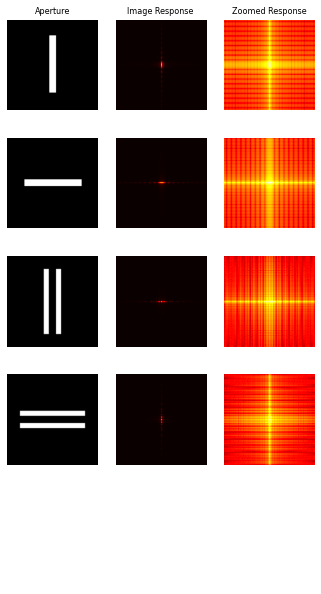

In [4]:
# Now we calculate the image response for slits ! 

single_slit_vertical = Image.open('Inputs/AA_single_slit.png')
single_slit_vertical_GS = np.array(single_slit_vertical.convert('L'))

single_slit_horizontal = Image.open('Inputs/AB_single_slit.png')
single_slit_horizontal_GS = np.array(single_slit_horizontal.convert('L'))

double_slit_vertical = Image.open('Inputs/AA_double_slit.png')
double_slit_vertical_GS = np.array(double_slit_vertical.convert('L'))

double_slit_horizontal = Image.open('Inputs/AB_double_slit.png')
double_slit_horizontal_GS = np.array(double_slit_horizontal.convert('L'))

gratings = Image.open('Inputs/Gratings.png')
gratings_GS = np.array(gratings.convert('L'))

# plt.axis('off')
# plt.imshow(single_slit_vertical_GS, cmap='gray')
# plt.imshow(single_slit_horizontal_GS, cmap='gray')
# plt.imshow(double_slit_vertical_GS, cmap='gray')
# plt.imshow(double_slit_vertical_GS, cmap='gray')

fourier_sslit_hrz_shifted_abs = diffraction_pattern(single_slit_vertical_GS)# this is the image response
fourier_sslit_ver_shifted_abs = diffraction_pattern(single_slit_horizontal_GS)
fourier_dslit_hrz_shifted_abs = diffraction_pattern(double_slit_horizontal_GS)
fourier_dslit_ver_shifted_abs = diffraction_pattern(double_slit_vertical_GS)
fourier_gratings_shifted_abs = diffraction_pattern(gratings_GS)



fig, ax = plt.subplots(5,3) 
    
ax[0,0].imshow(single_slit_vertical_GS, cmap='gray')
ax[0,1].imshow(fourier_sslit_ver_shifted_abs, cmap='hot')
ax[0,2].imshow(np.log(fourier_sslit_ver_shifted_abs), cmap='hot') # log scale for visualization
ax[1,0].imshow(single_slit_horizontal_GS, cmap='gray')
ax[1,1].imshow(fourier_sslit_hrz_shifted_abs, cmap='hot')
ax[1,2].imshow(np.log(fourier_sslit_hrz_shifted_abs), cmap='hot')
ax[2,0].imshow(double_slit_vertical_GS, cmap='gray')
ax[2,1].imshow(fourier_dslit_ver_shifted_abs, cmap='hot')
ax[2,2].imshow(np.log(fourier_dslit_ver_shifted_abs), cmap='hot')
ax[3,0].imshow(double_slit_horizontal_GS, cmap='gray')
ax[3,1].imshow(fourier_dslit_hrz_shifted_abs, cmap='hot')
ax[3,2].imshow(np.log(fourier_dslit_hrz_shifted_abs), cmap='hot')


ax[0,0].set_title('Aperture', fontsize = '8')
ax[0,1].set_title('Image Response', fontsize = '8')
ax[0,2].set_title('Zoomed Response', fontsize = '8')

for i in range(0,5):
    for j in range(0,3):
        ax[i,j].axis('off')

fig.set_size_inches(5.5, 10.5, forward=False)
fig.savefig('Results/Aperture Image Response',dpi=500)

In [5]:
img = Image.open('Inputs/House.png')
GS = np.array(img.convert('L'))

# plt.axis('off')
# plt.imshow(GS, cmap='gray')

In [6]:
fourier_img_1 = np.fft.fft2(GS)
fourier_img_1_abs = np.abs(fourier_img_1)
fourier_img_2 = np.fft.fft2(fourier_img_1)
fourier_img_2_abs = np.abs(fourier_img_2)
# plt.axis('off')
# plt.imshow(fourier_img_2_abs, cmap='gray')  # applied fft2 twice

In [7]:
ifourier_img_2 = np.fft.ifft2(fourier_img_1)
ifourier_img_2_abs = np.abs(ifourier_img_2)

# plt.axis('off')
# plt.imshow(ifourier_img_2_abs, cmap='gray') # applied fft then ifft

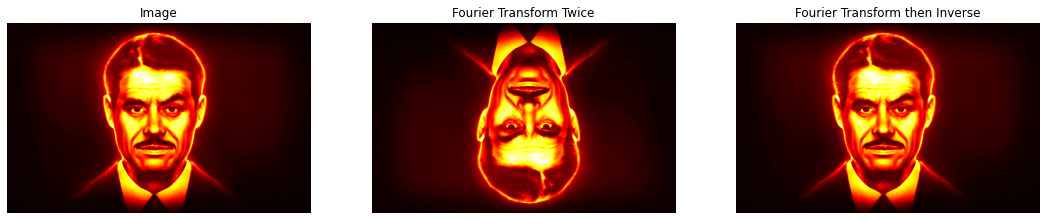

In [8]:
fig, ax = plt.subplots(1,3)

ax[0].imshow(GS, cmap='hot')
ax[1].imshow(fourier_img_2_abs, cmap='hot')
ax[2].imshow(ifourier_img_2_abs, cmap='hot')

ax[0].set_title('Image')
ax[1].set_title('Fourier Transform Twice')
ax[2].set_title('Fourier Transform then Inverse')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')

fig.set_size_inches(18.5, 10.5, forward=True)
fig.savefig('Results/2D Fourier Transform',dpi=1000)

# Act 2.2. Simulation of an Imaging System

In [9]:
img_2 = Image.open('Inputs/NIP.png')           # this is the NIP image
NIP = np.array(img_2.convert('L'))
# plt.imshow(NIP, cmap='gray')

In [10]:
B = circle_gen(0.5, 256)   # we make a 2nd circle

# plt.axis('off')
# plt.title('Human Eye Approximation')
# plt.imshow(B, cmap='gray')

In [11]:
N = 256
x = np.linspace(-1, 1, num=N)
y = x
X, Y = np.meshgrid(x,y)
R = np.sqrt(X**2 + Y**2)

B_cataract = np.zeros(np.shape(R))

B_cataract[np.where(R<0.5)] = 1
B_cataract[np.where(R<0.2)] = 0


C_cataract = np.zeros(np.shape(R))
C_cataract[np.where(R<0.5)] = 1
C_cataract[np.where(R<0.05)] = 0

# plt.axis('off')
# plt.title('Human Eye with Cataract')
# plt.imshow(B_cataract, cmap = 'gray')

1.0


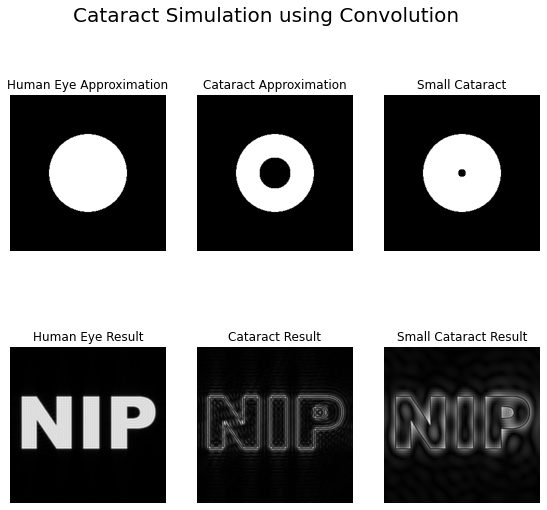

In [12]:
def convolution(aperture, target):     # make sure the two have same dimensions cuz we will multiply
    
    aperture_shifted = np.fft.fftshift(aperture)
    target_fft2 = np.fft.fft2(target)
    
    H = aperture_shifted * target_fft2
    h = np.fft.ifft2(H)    # inverse transform 
    
    return h  # this is a complex valued function, take abs() if you want to apply to real world 


NIP_conv_eye = convolution(B, NIP)
NIP_conv_cataract = convolution(B_cataract, NIP)
NIP_conv_smolcataract = convolution(C_cataract, NIP)
NIP_conv_eye_abs = np.abs(convolution(B, NIP))
NIP_conv_cataract_abs = np.abs(convolution(B_cataract, NIP))
NIP_conv_smolcataract_abs = np.abs(convolution(C_cataract, NIP))

fig, ax = plt.subplots(2, 3)

ax[0,0].imshow(B, cmap = 'gray')
ax[0,1].imshow(B_cataract, cmap = 'gray')
ax[0,2].imshow(C_cataract, cmap='gray')
ax[1,0].imshow(NIP_conv_eye_abs, cmap = 'gray')
ax[1,1].imshow(NIP_conv_cataract_abs, cmap = 'gray')
ax[1,2].imshow(NIP_conv_smolcataract_abs, cmap='gray')


ax[0,0].set_title('Human Eye Approximation')
ax[0,1].set_title('Cataract Approximation')
ax[0,2].set_title('Small Cataract')
ax[1,0].set_title('Human Eye Result')
ax[1,1].set_title('Cataract Result')
ax[1,2].set_title('Small Cataract Result')

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[1,0].axis('off')
ax[1,1].axis('off')
ax[1,2].axis('off')

fig.set_size_inches(9.5, 8.5, forward=True)

fig.suptitle('Cataract Simulation using Convolution', fontsize='20')
fig.savefig('Results/Cataract Simulation using Convolution',dpi=1000)

In [ ]:
# PUT CODE HERE, SIMULATE A CAMERA OBSCURA BY CHANING PINHOLE SIZE

In [ ]:
N = 585       # the James Webb Telescope image has this resolution

x = np.linspace(-1, 1, num=N)
y = x
X, Y = np.meshgrid(x,y)


R = np.sqrt(X**2 + Y**2)
C = np.zeros(np.shape(R))

C[np.where(R<0.03)] = 1   # C represents the star
# plt.axis('off')
# plt.title('Star to be Observed by James Webb')
# plt.imshow(C, cmap = 'gray')

img_3 = Image.open('Inputs/james_webb_telescope.png')
James_Webb = np.array(img_3.convert('L'))    # this is the James Webb image 
# MY CLASSMATE ONIN IS THE CREDITS (Nino Ramones)


# plt.axis('off')
# plt.imshow(James_Webb, cmap='gray')

star_conv_jameswebb = convolution(James_Webb, C)
star_conv_jameswebb_abs = np.abs(star_conv_jameswebb)
# plt.imshow(np.abs(star_conv_jameswebb), cmap='gray')

In [ ]:
fig, ax = plt.subplots(1,3)

ax[0].imshow(James_Webb, cmap='gray')
ax[1].imshow(C, cmap='gray')
ax[2].imshow(star_conv_jameswebb_abs, cmap='gray')

ax[0].set_title('Aperture')
ax[1].set_title('Object')
ax[2].set_title('Image Captured')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')



fig.set_size_inches(18.5, 10.5, forward=True)
fig.savefig('Results/James Webb',dpi=1200)

# Act 2.3. Template Matching using Correlation

In [ ]:
def correlation(detail, noise): # We will find details (A) in the noise (the phrase)
                              # make sure that both images are the same size
    detail_fft2 = np.fft.fft2(detail)
    noise_fft2 = np.fft.fft2(noise)
    detail_fft2_conjugate = np.conjugate(detail_fft2)
    
    P = detail_fft2_conjugate * noise_fft2
    p = np.fft.ifft2(P)
    
    return p   # NOTE: this is complex valued, use abs() if you want to show 


img_4 = Image.open('Inputs/spain.png')
spain = np.array(img_4.convert('L'))
# plt.axis('off')
# plt.imshow(spain, cmap='gray')

img_5 = Image.open('Inputs/A.png')
letter_A = np.array(img_5.convert('L'))
# plt.axis('off')
# plt.imshow(letter_A, cmap='gray')

img_6 = Image.open('Inputs/I.png')
letter_I = np.array(img_6.convert('L'))

correlate_A_abs = np.abs(correlation(letter_A, spain))
correlate_B_abs = np.abs(correlation(letter_I, spain))

fig,ax = plt.subplots(1, 3)

ax[0].imshow(spain, cmap='gray')
ax[1].imshow(np.fft.fftshift(correlate_A_abs), cmap='turbo')
ax[2].imshow(np.fft.fftshift(correlate_B_abs), cmap='turbo')

ax[0].set_title('Phrase')
ax[1].set_title('Finding A')
ax[2].set_title('Finding I')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')

fig.set_size_inches(18.5, 10.5, forward=True)
fig.savefig('Results/Image Correlation',dpi=1200)

In [ ]:
img_7 = Image.open('Inputs/Fallout_Factions.png')
fallout_flags = np.array(img_7.convert('L'))

img_8 = Image.open('Inputs/Legion_Faction.png')
caesar_legion = np.array(img_8.convert('L'))

img_9 = Image.open('Inputs/NewVegas_Money.png')
mojave_money = np.array(img_9.convert('L'))

img_10 = Image.open('Inputs/Nuka_Cola.png')
nuka_cola_cap = np.array(img_10.convert('L'))

correlate_legion_abs = np.abs(correlation(caesar_legion, fallout_flags))
correlate_money_abs = np.abs(correlation(nuka_cola_cap, mojave_money))

# plt.imshow(correlate_money_abs, cmap = 'turbo')

fig,ax = plt.subplots(2, 3)

ax[0,0].imshow(fallout_flags, cmap='gray')
ax[0,1].imshow(caesar_legion, cmap='gray')
ax[0,2].imshow(correlate_legion_abs, cmap='turbo')

ax[1,0].imshow(mojave_money, cmap='gray')
ax[1,1].imshow(nuka_cola_cap, cmap='gray')
ax[1,2].imshow(correlate_money_abs, cmap='turbo')

ax[0,0].set_title('Initial Image', fontsize='20')
ax[0,1].set_title('Element to be Searched', fontsize='20')
ax[0,2].set_title('Heat Map', fontsize='20')

for i in range(0, 2):
    for j in range(0,3):
        ax[i,j].axis('off')


fig.set_size_inches(18.5, 7.5, forward=True)
fig.savefig('Results/Arbirtrary Image Correlation',dpi=500)